# Telco Customer Churn — Exploratory Data Analysis (EDA)

Is notebook mein hum dataset ko explore karte hain training se pehle:
- Churn distribution
- Categorical features vs churn
- Numeric features vs churn
- Correlation heatmap

**Note:** Actual production pipeline (preprocessing + training + tuning) `src/` folder ki `.py` files mein hai.
Ye notebook sirf analysis/visualization ke liye hai.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load Data

In [4]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## 2. Clean Data\n\n`Total Charges` mein kuch blank strings hain (naye customers, tenure=0). Unko numeric NaN bana dete hain.

In [6]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print("Missing Total Charges:", df["Total Charges"].isnull().sum())
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

Missing Total Charges: 11


## 3. Target Distribution — Churn Value

Churn Value
0    5174
1    1869
Name: count, dtype: int64
Churn Rate: 26.54%


C:\Users\abdul\AppData\Local\Temp\ipykernel_11924\3595696515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn Label", data=df, palette=["#4C72B0", "#DD8452"])


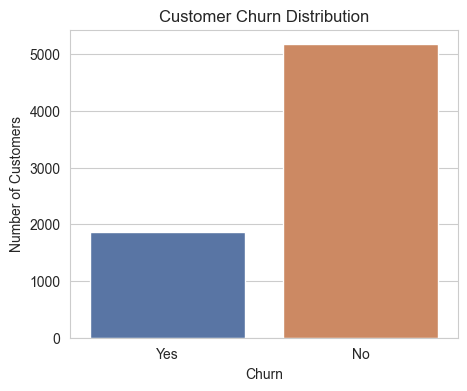

In [7]:
churn_counts = df["Churn Value"].value_counts()
print(churn_counts)
print(f"Churn Rate: {churn_counts[1] / len(df):.2%}")

plt.figure(figsize=(5,4))
sns.countplot(x="Churn Label", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** Dataset thoda imbalanced hai (~73% No Churn, ~27% Churn). Isi liye training mein humne `scoring="f1"` use kiya GridSearchCV mein, sirf accuracy nahi (accuracy imbalanced data pe misleading hoti hai).

## 4. Contract Type vs Churn

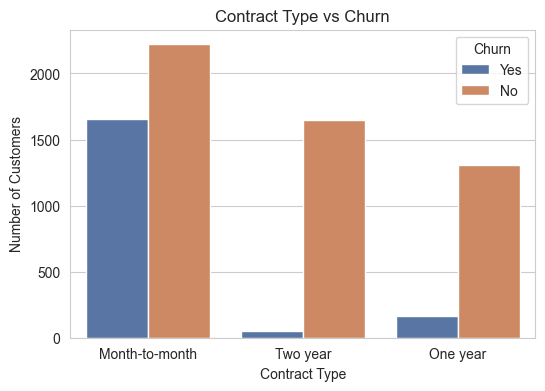

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn Label", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

**Observation:** Month-to-month contract wale customers sabse zyada churn karte hain — ye ek strong predictive feature lagta hai.

## 5. Monthly Charges vs Churn

C:\Users\abdul\AppData\Local\Temp\ipykernel_11924\1440951899.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn Label", y="Monthly Charges", data=df, palette=["#4C72B0", "#DD8452"])


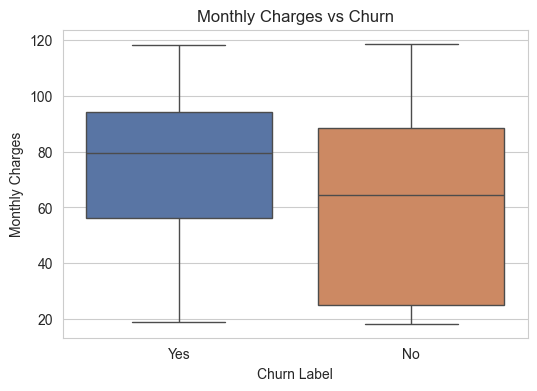

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Monthly Charges vs Churn")
plt.show()

## 6. Tenure vs Churn

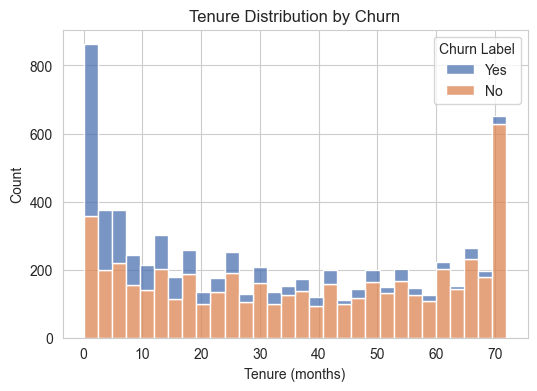

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Tenure Months", hue="Churn Label", multiple="stack",
             palette=["#4C72B0", "#DD8452"], bins=30)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.show()

**Observation:** Naye customers (kam tenure) mein churn rate zyada hai — jaise jaise tenure barhta hai, churn kam hota jata hai.

## 7. Internet Service & Tech Support vs Churn

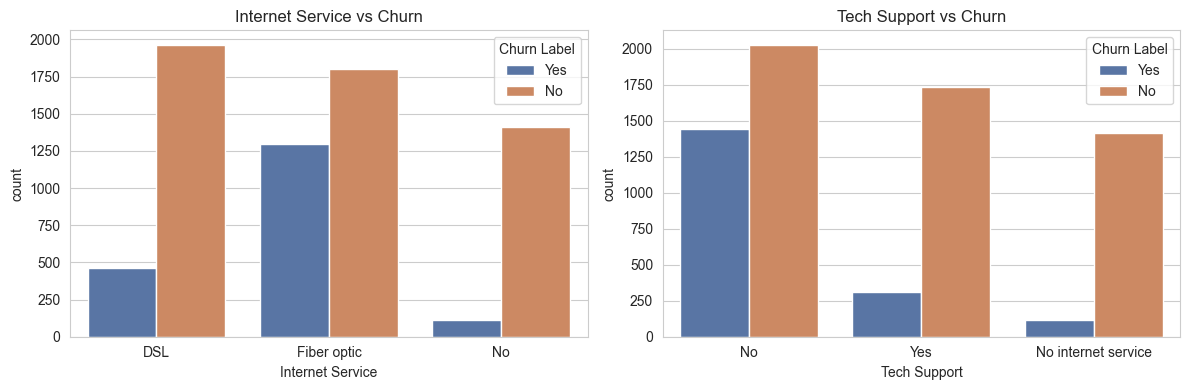

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x="Internet Service", hue="Churn Label", data=df,
              palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Internet Service vs Churn")

sns.countplot(x="Tech Support", hue="Churn Label", data=df,
              palette=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("Tech Support vs Churn")

plt.tight_layout()
plt.show()

**Observation:** Fiber optic users aur jinke paas Tech Support nahi hai, unmein churn zyada hai.

## 8. Correlation Heatmap (Numeric Features)

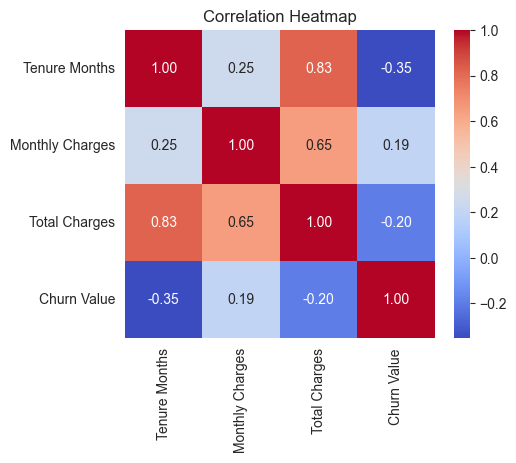

In [12]:
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value"]

plt.figure(figsize=(5,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** Tenure ka Churn Value ke sath negative correlation hai (jitna zyada tenure, utna kam churn chance).

## 9. Summary of Key Insights

- Dataset imbalanced hai (~27% churn) → F1/ROC-AUC scoring zyada meaningful hai accuracy se
- **Month-to-month contract**, **short tenure**, **Fiber optic internet**, aur **no tech support** — ye sab churn ke strong indicators hain
- **High Monthly Charges** wale customers bhi zyada churn karte hain
- Ye insights training pipeline (`src/train.py`) mein use hui feature engineering ki justification dete hain — koi bhi feature blindly nahi choose ki gayi, EDA se validate hui hai

Agla step: `src/train.py` chalayen jo yehi features use kar ke Logistic Regression aur Random Forest ko GridSearchCV se compare karta hai.